In [5]:
import pandas as pd
import re
import emoji
import numpy as np
import swifter
import nltk
d=pd.read_csv("raw_tweets_text.csv",nrows=100000)
d.head()

,id,text
0,758014713804587008,RT @polarcomic: And surprise! the #RegularShow...
1,758014717990428672,RT @SweetBabyBellB: My unproblematic fav who k...
2,758014646716665857,RT @WhyLarryIsReal: I mean we know harry isn't...
3,758014655071526912,"RT @Eastbay: She's ready, resilient, and on ou..."
4,758014642526429184,RT @SheeeRatchet: find someone who loves you a...


In [6]:
def has_emoji(text):
    if not isinstance(text,str):
        return False
    return emoji.emoji_count(text)>0

#Clean text
def clean_tweet(text):
    if not isinstance(text,str):
        return [], False, ""
    
    emojis=[c for c in text if c in emoji.EMOJI_DATA]
    has_emoji=bool(emojis)
    text=emoji.demojize(text,language='en') #demojize text
    text=re.sub(r":([a-z_]+):",r" emoji_\1",text)

    text=text.lower() #lower text

    #Transform emoticons to tokens
    emoticon_dict = {":)": "emoji_smile", ":-)": "emoji_smile",
                     ":(": "emoji_sad", ":-(": "emoji_sad",
                     ":D": "emoji_laugh", ";)": "emoji_wink"}
    
    for emo, token in emoticon_dict.items():
        text=text.replace(emo, f" {token} ")

    text=re.sub(r"https?://\S+|www\.\S+","",text) #remove URLs
    text=re.sub(r"@\w+","",text) #remove mention
    text=re.sub(r"\brt\b","",text) #remove retweet
    text=re.sub(r"#(\w+)",r"\ hashtag_\1",text) # remove hashtag
    text=re.sub(r"\d+","",text) #remove numbers
    text=re.sub(r"(.)\1{3,}",r"\1\1\1",text) #limit repeated characters to 3
    return emojis, has_emoji, " ".join(text.split()).strip()

#Transform emoji in token
def demojize_text(text):
    text=emoji.demojize(text,language='en')
    text=re.sub(r":([a-z_]+):",r" emoji_\1",text)
    return text

def extract_emojis(text):
    return [char for char in text if char in emoji.EMOJI_DATA]

df_tweet=d.copy()

df_tweet[["emojis","has_emoji","text_clean"]]=(
    df_tweet["text"].apply(clean_tweet).apply(pd.Series)
)
df_tweet.sample(10)

,id,text,emojis,has_emoji,text_clean
946068,781397941844082688,https://t.co/m4licaVKHo #0484 CDMA A1349/GSM A...,[],False,\ hashtag_ cdma a/gsm a touch digitizer lcd gl...
966411,781529580083482624,What you need to know about tomorrow's big Rog...,[],False,what you need to know about tomorrow's big rog...
436436,768697069225652224,RT @BestOfGalaxies: The Northern Lights over N...,[],False,: the northern lights over norway
942320,781363796002631681,@VFomal on TV!!! https://t.co/XzsjgKyfc3,[],False,on tv!!!
930691,781274490881777664,"Come join me, or you'll be left behind #BIGOLI...",[],False,"come join me, or you'll be left behind \ hasht..."
452083,768739662370222081,RT @Scrupulous_Tad: @GurmeetramrahimJust by fo...,[],False,": by following,what \ hashtag_msgsays ,masses ..."
734164,769504636332113920,"RT @GlemdaGaming: The Sombra ARG - Simple, Ful...",[],False,": the sombra arg - simple, full summary by ham..."
429176,768678677219569664,#TRY https://t.co/5sZSzqrdBm Pot. consolid in ...,[],False,\ hashtag_try pot. consolid in uptrend intrawe...
548892,769119200749182976,RT @sneakers_game: Asics Gel Lyte V x Offsprin...,[],False,": asics gel lyte v x offspring ""desert pack"" ()"
632987,769273391752679424,Asian boys sex jerk off Straight dude goes - #...,[],False,asian boys sex jerk off straight dude goes - \...


In [7]:
import contractions
import string
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords,wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

#Setup NLTK
tokenizer=TweetTokenizer(preserve_case=False)
sentence_breakers = {'.', '!', '?', ';', ':','but','however','although','though','even though','whereas'}
negation_words = {'not','no','never','neither','nor',
                  "can't","cannot","don't","didn't","doesn't","isn't","wasn't","weren't","ain't"}
stopwords_set=set(stopwords.words('english'))-negation_words
lemmatizer=WordNetLemmatizer()

sentence_breakers = {'.', '!', '?', ';', ':','but','however','although','though','even though','whereas'}

NEG=3 #Number of words after which negation effect ends

fix_contractions=contractions.fix
tokenize=tokenizer.tokenize
pos_tag_fn=pos_tag
lemmatize=lemmatizer.lemmatize

#Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'): 
        return wordnet.NOUN
    elif tag.startswith('R'): 
        return wordnet.ADV
    else:
        return wordnet.NOUN #Default

def lemmatize_tokens(tokens):
    alpha_tokens=[t for t in tokens if t.isalpha()]
    tagged_tokens=pos_tag_fn(alpha_tokens)
    tag_map=dict(tagged_tokens)

    final=[]
    negation=0
    for word, tag in tagged_tokens:
        word_lower=word.lower()

        if word_lower in sentence_breakers or word in string.punctuation:
            negation=0
            final.append(word)
            continue

        if word_lower.startswith("emoji_"):
            prefix="NOT_" if negation>0 else ""
            final.append(prefix+word_lower)
            if negation>0:
                negation-=1
            continue
        
        if word_lower.isalpha():
            lemma=lemmatize(word_lower,get_wordnet_pos(tag))
            if word_lower in negation_words:
                negation=NEG
                final.append(lemma)
            elif negation>0:
                final.append("NOT_"+lemma)
                negation-=1
            else:
                final.append(lemma)
        else:
            final.append(word_lower)
                    
    return final

def tokenize_lemmatize(text):
    if not isinstance(text,str):
        return []
    text=fix_contractions(text)
    tokens=tokenize(text)
    return lemmatize_tokens(tokens)

df_tweet["final_tokens"]=df_tweet["text_clean"].apply(tokenize_lemmatize)
df_tweet.sample(10)


,id,text,emojis,has_emoji,text_clean,final_tokens
869772,780871464392286208,"Photo by laurs29, #irlande #irish #2016 https:...",[],False,"photo by laurs, \ hashtag_irlande \ hashtag_ir...","[photo, by, laurs, hashtag]"
713784,769451108611809280,RT @NimbleNavgater: The Clinton campaign wrapp...,[],False,: the clinton campaign wrapped into image.,"[the, clinton, campaign, wrap, into, image]"
643301,769292572309217280,RT @HillaryClinton: Trump hired the head of Br...,[],False,": trump hired the head of breitbart ""news"" to ...","[trump, hire, the, head, of, breitbart, news, ..."
282366,768299692488740864,RT @jlawmaximoff: since gregg sulkin and bella...,[],False,: since gregg sulkin and bella thorne are over...,"[since, gregg, sulkin, and, bella, thorne, be,..."
239385,768211872147320833,"After career year, Seahawks’ Doug Baldwin is r...",[],False,"after career year, seahawks’ doug baldwin is r...","[after, career, year, seahawks, doug, baldwin,..."
405315,768628790142599169,RT @metmuseum: This installation explores mult...,[],False,: this installation explores multifaceted depi...,"[this, installation, explore, multifaceted, de..."
46525,758073069181231104,Everyone needs to be as happy as @kourtbaybayy...,[],False,everyone needs to be as happy as washing her car.,"[everyone, need, to, be, as, happy, a, wash, h..."
334081,768493238617419777,RT @SakajaJohnson: Float like a butterfly and ...,[],False,": float like a butterfly and sting like a bee,...","[float, like, a, butterfly, and, sting, like, ..."
316581,768460338500993024,"RT @TheTruth24US: This cut would be stunning, ...",[],False,": this cut would be stunning, if it wasn’t the...","[this, cut, would, be, stun, if, it, be, not, ..."
2241,758017805027569664,When you see @GraysonDolan and @EthanDolan ret...,[],False,when you see and retweet all these tweets besi...,"[when, you, see, and, retweet, all, these, twe..."


In [17]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB,MultinomialNB
from sklearn.metrics import classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

emoji_db=pd.read_csv("Emoji_Sentiment.csv",encoding="utf-8") #Dataset with emoji sentiment scores
emoji_db["score"]=(emoji_db["Positive"]-emoji_db["Negative"])/(emoji_db["Positive"]+emoji_db["Negative"]+emoji_db["Neutral"]) #Calculate sentiment score as normalized difference
emoji_lookup=dict(zip(emoji_db["Emoji"],emoji_db["score"]))

sia=SentimentIntensityAnalyzer()#Inizialize VADER sentiment analyzer

def get_score_emoji(emoji_list):
    if not emoji_list:
        return 0.0
    score=[emoji_lookup.get(e,0.0) for e in emoji_list]
    return sum(score)/len(score)

#Function to convert VADER compound score to labels
def vader_label(text_score,margin=0.05):
    if text_score>margin:
        return "Positive"
    elif text_score<-margin:
        return "Negative"
    else:
        return "Neutral"
    
df_tweet["text_score"]=df_tweet["text_clean"].apply(lambda x: sia.polarity_scores(str(x))['compound'] if isinstance(x, str) else 0.0)
df_tweet["sentiment"] = df_tweet["text_score"].apply(vader_label)


#Calculate emoji score using another dataset
df_tweet["emoji_score"]=df_tweet["emojis"].apply(get_score_emoji)

print("Distribuzione sentiment:", df_tweet["sentiment"].value_counts())

#Prepare Features & Target
X_text=df_tweet["final_tokens"].apply(lambda t: " ".join(t)) #Join tokens into string
X_extra=df_tweet[["emoji_score"]].values #Emoji score as a numeric feature
y=df_tweet["sentiment"] #Target sentiment

#Train/test split
X_train_text, X_test_text, X_train_extra,X_test_extra,y_train,y_test=train_test_split(X_text,X_extra,y,test_size=0.2,random_state=42,stratify=y)

#TF-IDF
tfidf=TfidfVectorizer(ngram_range=(1,3),min_df=5,max_df=0.8,sublinear_tf=True,max_features=50000) #Consider unigrams to n-grams, ignore rare terms (min_df), ignore very common terms (max_df) and 
#apply logarithmic scaling to term frequency
X_train_tfidf=tfidf.fit_transform(X_train_text)
X_test_tfidf=tfidf.transform(X_test_text)

scaler=StandardScaler(with_mean=False)

X_train_extra_scaled=scaler.fit_transform(X_train_extra)
X_test_extra_scaled=scaler.transform(X_test_extra)

#Emoji score shift for Naive Bayes
X_train_extra_nb=X_train_extra+1 #shift [-1,1]->[0,2]
X_test_extra_nb=X_test_extra+1

X_train_final_nb=hstack([X_train_tfidf,X_train_extra_nb])
X_test_final_nb=hstack([X_test_tfidf,X_test_extra_nb])

#With weighting emoji score
X_train_extra_scaled_weighted=X_train_extra_scaled*0.8
X_test_extra_scaled_weighted=X_test_extra_scaled*0.8

#Union of TF-IDF features and emoji_score
X_train_final_lr=hstack([X_train_tfidf,X_train_extra_scaled_weighted])
X_test_final_lr=hstack([X_test_tfidf,X_test_extra_scaled_weighted])


df_tweet.sample(10)

Distribuzione sentiment: sentiment
Neutral     451126
Positive    398307
Negative    150567
Name: count, dtype: int64


,id,text,emojis,has_emoji,text_clean,final_tokens,text_score,sentiment,emoji_score
127065,758186067899985920,"RT @PotterWorldUK: It was on this day, 25 year...",[],False,": it was on this day, years ago, that harry po...","[it, be, on, this, day, year, ago, that, harry...",0.0000,Neutral,0.000000
980897,781609578039504896,#photography #image #photo The Mountain Sea by...,[],False,\ hashtag_photography \ hashtag_image \ hashta...,"[the, mountain, sea, by, maphoto]",0.0000,Neutral,0.000000
197004,768134214600495104,RT @Ashton5SOS: See you tonight Omaha 😘💘 xx @5...,"[😘, 💘]",True,: see you tonight omaha emoji_face_blowing_a_k...,"[see, you, tonight, omaha, xx]",0.0000,Neutral,0.695181
644999,769295692871249921,"RT @Fala7i_King: ""Hey would you like to come i...",[],False,": ""hey would you like to come into work today?""","[hey, would, you, like, to, come, into, work, ...",0.3612,Positive,0.000000
343417,768508942125260800,Baileys (20)sweet..strong..dizzyhttps://t.co/J...,[],False,baileys ()sweet..strong..dizzy,"[bailey, sweet, strong, dizzy]",0.0000,Neutral,0.000000
783832,769598827825205248,RT @Myluck01: Here's where to get the baby Yee...,[],False,: here's where to get the baby yeezys on satur...,"[here, be, where, to, get, the, baby, yeezys, ...",0.0000,Neutral,0.000000
409126,768637027772461056,RT @iiheart_vee: wus good ;) https://t.co/yiMQ...,[],False,: wus good emoji_wink,"[wus, good]",0.4404,Positive,0.000000
662371,769329771578875904,RT @Bless_NYC: When you watching Chopped and a...,[],False,: when you watching chopped and a chef decides...,"[when, you, watch, chop, and, a, chef, decide,...",0.0000,Neutral,0.000000
601311,769216714152243200,RT @USCCB: Today’s Readings: https://t.co/4NN0...,[],False,: today’s readings:,"[today, s, reading]",0.0000,Neutral,0.000000
973996,781569883112865792,#AtlantaHorrorStory 👻😈🎃 RETURNS OCTOBER 29TH H...,"[👻, 😈, 🎃, 💃, 🏽, 🍾, 🎉]",True,\ hashtag_atlantahorrorstory emoji_ghost emoji...,"[return, october, th, halloween, meet, spelhou...",0.0000,Neutral,0.370363


Global Accuracy with MultinomialNB: 0.84

              precision    recall  f1-score   support

    Negative       0.81      0.65      0.72     30114
     Neutral       0.83      0.92      0.87     90225
    Positive       0.88      0.84      0.86     79661

    accuracy                           0.84    200000
   macro avg       0.84      0.80      0.82    200000
weighted avg       0.84      0.84      0.84    200000



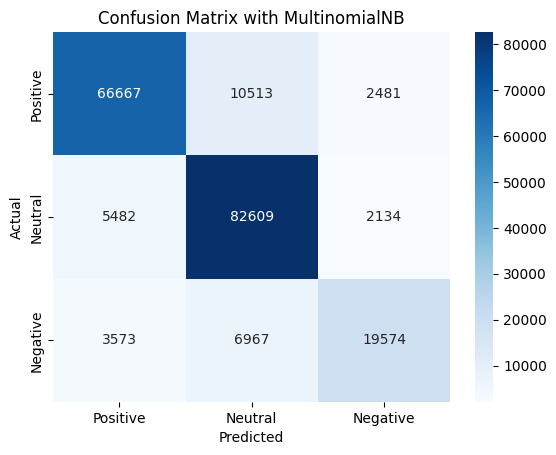

In [18]:
#Test usign MultinomialNB - Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Train Multinomial Naive Bayes classifier with Smoothing Laplace (alpha=1)
model=MultinomialNB(alpha=1)
model.fit(X_train_final_nb,y_train)
y_predMultinomial=model.predict(X_test_final_nb) #Predict and test

print(f"Global Accuracy with MultinomialNB: {accuracy_score(y_test,y_predMultinomial):.2f}\n")
print(classification_report(y_test,y_predMultinomial))
cm=confusion_matrix(y_test,y_predMultinomial,labels=["Positive","Neutral","Negative"])
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with MultinomialNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Global Accuracy with ComplementNB: 0.84

              precision    recall  f1-score   support

    Negative       0.71      0.82      0.76     30114
     Neutral       0.86      0.86      0.86     90225
    Positive       0.89      0.84      0.86     79661

    accuracy                           0.84    200000
   macro avg       0.82      0.84      0.83    200000
weighted avg       0.85      0.84      0.85    200000



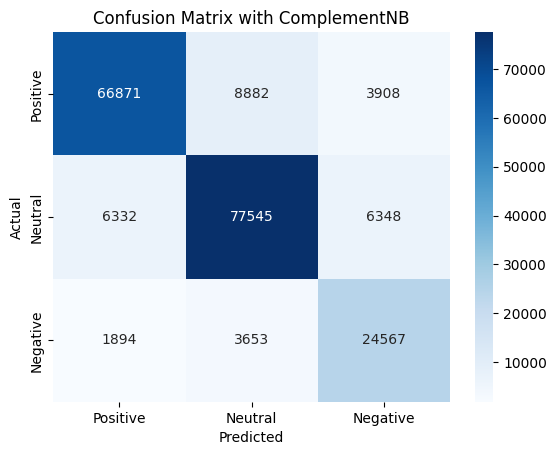

In [19]:
#Test using ComplementNB
model2=ComplementNB(alpha=1) #Using Laplace smoothing
model2.fit(X_train_final_nb,y_train)
y_predComplement=model2.predict(X_test_final_nb)
print(f"Global Accuracy with ComplementNB: {accuracy_score(y_test,y_predComplement):.2f}\n")
print(classification_report(y_test,y_predComplement))

cmw=confusion_matrix(y_test,y_predComplement,labels=["Positive","Neutral","Negative"])
sns.heatmap(cmw,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with ComplementNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

convergence after 89 epochs took 69 seconds
Global Accuracy with LogisticRegression: 0.94



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.2min finished


              precision    recall  f1-score   support

    Negative       0.86      0.92      0.89     30114
     Neutral       0.96      0.94      0.95     90225
    Positive       0.95      0.94      0.95     79661

    accuracy                           0.94    200000
   macro avg       0.92      0.94      0.93    200000
weighted avg       0.94      0.94      0.94    200000



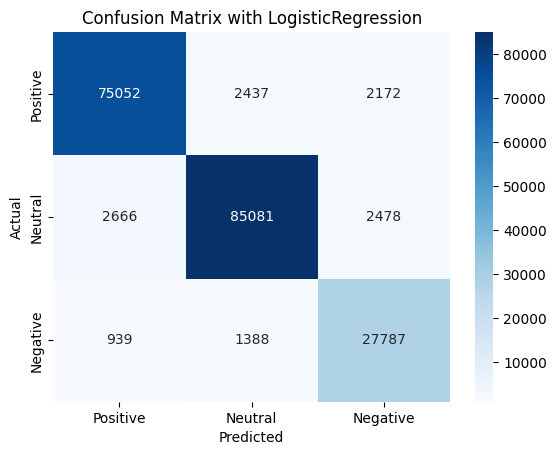

In [20]:
#Test using LogisticRegression
from sklearn.linear_model import LogisticRegression

modelLogistic=LogisticRegression(max_iter=1000,solver='saga',class_weight='balanced',C=2,verbose=1)
modelLogistic.fit(X_train_final_lr,y_train)

y_predRegression=modelLogistic.predict(X_test_final_lr)

print(f"Global Accuracy with LogisticRegression: {accuracy_score(y_test,y_predRegression):.2f}\n")
print(classification_report(y_test,y_predRegression))

cmr=confusion_matrix(y_test,y_predRegression,labels=["Positive","Neutral","Negative"])
sns.heatmap(cmr,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with LogisticRegression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()